In [36]:
!ls -lh *.zip *.txt 2>/dev/null || echo "No zip/txt files found"
!ls -lh

-rw-r--r--. 1 sagemaker-user users  38M Apr 19 11:54 aligned.zip
-rw-r--r--. 1 sagemaker-user users 3.7M Oct  9  2019 ckplus.zip
-rw-r--r--. 1 sagemaker-user users  61M Jul 19  2020 fer2013.zip
-rw-r--r--. 1 sagemaker-user users 279K Apr 19 11:35 list_patition_label.txt
total 330M
-rw-r--r--. 1 sagemaker-user users    38M Apr 19 11:54 aligned.zip
drwxr-xr-x. 4 sagemaker-user users     29 Apr  2 20:02 ckplus
-rw-r--r--. 1 sagemaker-user users   3.7M Oct  9  2019 ckplus.zip
-rw-r--r--. 1 sagemaker-user users    44M Apr 18 22:25 ckplus_best_model.pth
-rw-r--r--. 1 sagemaker-user users    44M Apr  2 21:18 ckplus_model_v2.pth
-rw-r--r--. 1 sagemaker-user users     72 Apr 18 22:25 class_names.json
-rw-r--r--. 1 sagemaker-user users    165 Apr 18 22:25 cognitive_load_map.json
-rw-r--r--. 1 sagemaker-user users    41K Apr 18 22:09 confusion_matrix.png
-rw-r--r--. 1 sagemaker-user users   4.9M Feb 21 13:23 emotion_model.pth
-rw-r--r--. 1 sagemaker-user users   4.9M Mar 24 14:49 emotion_model_v2

In [37]:
# Verify it's complete
!ls -lh aligned.zip
!unzip -t aligned.zip | tail -5

-rw-r--r--. 1 sagemaker-user users 38M Apr 19 11:54 aligned.zip
    testing: aligned/train_12268_aligned.jpg   OK
    testing: aligned/train_12269_aligned.jpg   OK
    testing: aligned/train_12270_aligned.jpg   OK
    testing: aligned/train_12271_aligned.jpg   OK
No errors detected in compressed data of aligned.zip.


In [1]:
!pip install torch torchvision matplotlib scikit-learn seaborn -q

# Fix kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle -q

# Download CK+
!kaggle datasets download -d shawon10/ckplus -q
!unzip -o -q ckplus.zip -d ckplus
print("✅ CK+ ready")

# Extract RAF-DB
!unzip -o -q aligned.zip -d rafdb
print("✅ RAF-DB extracted")

!echo "CK+ structure:"; ls ckplus
!echo "RAF-DB file count:"; ls rafdb/aligned | wc -l

Dataset URL: https://www.kaggle.com/datasets/shawon10/ckplus
License(s): CC0-1.0
✅ CK+ ready
✅ RAF-DB extracted
CK+ structure:
CK+48  ck
RAF-DB file count:
15339


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random
import json
import shutil
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Imports done")
print("Using device:", device)

✅ Imports done
Using device: cuda


In [3]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.2)
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✅ Transforms ready")

✅ Transforms ready


In [4]:
import shutil

RAFDB_LABEL_MAP = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sadness",
    "6": "anger",
    "7": "neutral"
}

label_file = "list_patition_label.txt"
image_dir  = "rafdb/aligned"
output_dir = "rafdb_organized"

# Create folder structure
for split in ["train", "test"]:
    for emotion in RAFDB_LABEL_MAP.values():
        os.makedirs(f"{output_dir}/{split}/{emotion}", exist_ok=True)

with open(label_file, "r") as f:
    lines = f.readlines()

train_count = 0
test_count  = 0
not_found   = 0

for line in lines:
    parts = line.strip().split()
    if len(parts) != 2:
        continue

    filename, label = parts[0], parts[1]
    emotion = RAFDB_LABEL_MAP.get(label, None)
    if emotion is None:
        continue

    split     = "train" if filename.startswith("train") else "test"
    base      = filename.replace(".jpg", "") + "_aligned.jpg"
    src       = os.path.join(image_dir, base)
    dst       = os.path.join(output_dir, split, emotion, base)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        if split == "train":
            train_count += 1
        else:
            test_count += 1
    else:
        not_found += 1

print(f"✅ RAF-DB organized!")
print(f"   Train: {train_count} | Test: {test_count} | Not found: {not_found}")
print(f"\nPer class (train):")
for emotion in RAFDB_LABEL_MAP.values():
    n = len(os.listdir(f"{output_dir}/train/{emotion}"))
    print(f"   {emotion:10s}: {n}")

✅ RAF-DB organized!
   Train: 12271 | Test: 3068 | Not found: 0

Per class (train):
   surprise  : 1290
   fear      : 281
   disgust   : 717
   happy     : 4772
   sadness   : 1982
   anger     : 705
   neutral   : 2524


In [5]:
rafdb_train = ImageFolder(root="rafdb_organized/train", transform=transform_train)
rafdb_test  = ImageFolder(root="rafdb_organized/test",  transform=transform_test)

print("RAF-DB classes:", rafdb_train.classes)
print("RAF-DB train:", len(rafdb_train))
print("RAF-DB test: ", len(rafdb_test))

RAF-DB classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
RAF-DB train: 12271
RAF-DB test:  3068


In [6]:
ckplus_full_train = ImageFolder(root='ckplus/CK+48', transform=transform_train)
ckplus_full_test  = ImageFolder(root='ckplus/CK+48', transform=transform_test)

print("CK+ classes:", ckplus_full_train.classes)

# Subject-aware split
subject_to_indices = defaultdict(list)
for idx, (path, label) in enumerate(ckplus_full_train.samples):
    filename   = os.path.basename(path)
    subject_id = filename.split('_')[0]
    subject_to_indices[subject_id].append(idx)

subjects = list(subject_to_indices.keys())
random.seed(42)
random.shuffle(subjects)
split = int(0.8 * len(subjects))

train_subjs = subjects[:split]
test_subjs  = subjects[split:]

ck_train_idx = [i for s in train_subjs for i in subject_to_indices[s]]
ck_test_idx  = [i for s in test_subjs  for i in subject_to_indices[s]]

ckplus_train = Subset(ckplus_full_train, ck_train_idx)
ckplus_test  = Subset(ckplus_full_test,  ck_test_idx)

print(f"CK+ train: {len(ckplus_train)} | test: {len(ckplus_test)}")
print(f"Subject overlap check: {len(set(train_subjs) & set(test_subjs))} ✅")

CK+ classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
CK+ train: 769 | test: 213
Subject overlap check: 0 ✅


In [7]:
# CK+ has 7 classes but no 'neutral'
# RAF-DB has 7 classes including 'neutral'
# We need to align them — only use CK+ classes that exist in RAF-DB

print("RAF-DB classes:", rafdb_train.classes)
print("CK+     classes:", ckplus_full_train.classes)

# Final class list — RAF-DB order is our standard
CLASS_NAMES = rafdb_train.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nFinal classes ({NUM_CLASSES}):", CLASS_NAMES)

# Combine
combined_train = ConcatDataset([rafdb_train, ckplus_train])
combined_test  = ConcatDataset([rafdb_test,  ckplus_test])

print(f"\nCombined train: {len(combined_train)}")
print(f"Combined test:  {len(combined_test)}")

train_loader = DataLoader(
    combined_train, batch_size=32, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    combined_test, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True
)

print("✅ DataLoaders ready")

RAF-DB classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
CK+     classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

Final classes (7): ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

Combined train: 13040
Combined test:  3281
✅ DataLoaders ready


In [18]:
# Run this BEFORE the training cell above
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

print("✅ Model reset to fresh weights")

✅ Model reset to fresh weights


In [19]:
# Calculate class weights to fix imbalance
train_counts = {
    "anger":    705,
    "disgust":  717,
    "fear":     281,
    "happy":    4772,
    "neutral":  2524,
    "sadness":  1982,
    "surprise": 1290
}

total = sum(train_counts.values())
weights = []
for cls in CLASS_NAMES:
    w = total / (len(CLASS_NAMES) * train_counts[cls])
    weights.append(w)
    print(f"  {cls:10s}: weight = {w:.3f}")

class_weights = torch.FloatTensor(weights).to(device)

# ✅ Weighted loss — fixes sadness/surprise bias
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=3
)

best_accuracy = 0

for epoch in range(50):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    scheduler.step(epoch_loss)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "lumen_best_model.pth")
        print(f"  ✅ New best saved!")

    print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}% | Best: {best_accuracy:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

  anger     : weight = 2.487
  disgust   : weight = 2.445
  fear      : weight = 6.238
  happy     : weight = 0.367
  neutral   : weight = 0.695
  sadness   : weight = 0.884
  surprise  : weight = 1.359
  ✅ New best saved!
Epoch 01 | Loss: 1.8845 | Val Acc: 63.46% | Best: 63.46% | LR: 0.000300
Epoch 02 | Loss: 1.6407 | Val Acc: 58.09% | Best: 63.46% | LR: 0.000300
Epoch 03 | Loss: 1.5421 | Val Acc: 63.46% | Best: 63.46% | LR: 0.000300
  ✅ New best saved!
Epoch 04 | Loss: 1.4621 | Val Acc: 63.73% | Best: 63.73% | LR: 0.000300
  ✅ New best saved!
Epoch 05 | Loss: 1.4290 | Val Acc: 72.11% | Best: 72.11% | LR: 0.000300
Epoch 06 | Loss: 1.3870 | Val Acc: 71.53% | Best: 72.11% | LR: 0.000300
  ✅ New best saved!
Epoch 07 | Loss: 1.3460 | Val Acc: 72.36% | Best: 72.36% | LR: 0.000300
Epoch 08 | Loss: 1.3187 | Val Acc: 72.30% | Best: 72.36% | LR: 0.000300
  ✅ New best saved!
Epoch 09 | Loss: 1.2908 | Val Acc: 73.54% | Best: 73.54% | LR: 0.000300
Epoch 10 | Loss: 1.2812 | Val Acc: 73.42% | Best:

              precision    recall  f1-score   support

       anger       0.83      0.74      0.78       195
     disgust       0.53      0.63      0.57       163
        fear       0.68      0.77      0.72       119
       happy       0.94      0.91      0.92      1194
     neutral       0.82      0.80      0.81       719
     sadness       0.78      0.86      0.82       505
    surprise       0.88      0.82      0.85       386

    accuracy                           0.84      3281
   macro avg       0.78      0.79      0.78      3281
weighted avg       0.84      0.84      0.84      3281



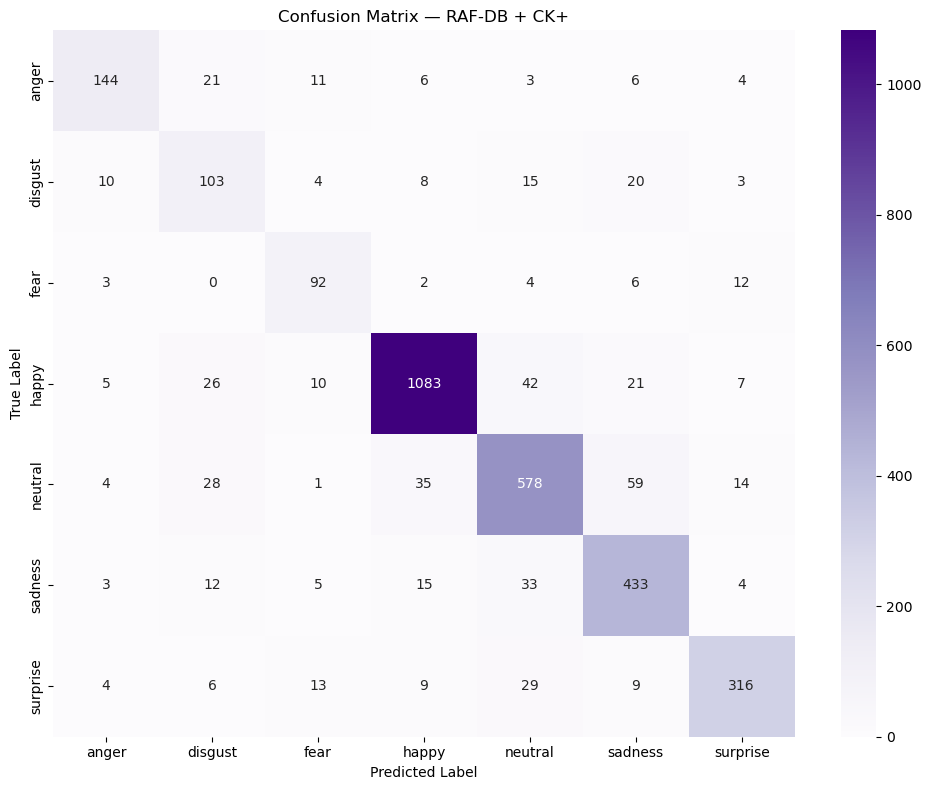

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("lumen_best_model.pth"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — RAF-DB + CK+")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_rafdb_ckplus.png")
plt.show()

In [21]:
%%writefile inference.py

import os, io, json, base64, traceback
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as tvmodels
from PIL import Image

CLASS_NAMES = ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]

COGNITIVE_LOAD_MAP = {
    "anger":    "High Load",
    "disgust":  "High Load",
    "fear":     "High Load",
    "sadness":  "High Load",
    "surprise": "Optimal Load",
    "neutral":  "Optimal Load",
    "happy":    "Low Load"
}

def model_fn(model_dir):
    try:
        device = torch.device("cpu")
        net = tvmodels.resnet18(weights=None)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, len(CLASS_NAMES))
        )
        model_file = next(
            (os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")),
            None
        )
        if not model_file:
            raise FileNotFoundError("No .pth found in " + model_dir)
        net.load_state_dict(torch.load(model_file, map_location=device))
        net.eval()
        print("✅ Model loaded:", model_file)
        return net
    except Exception:
        traceback.print_exc()
        raise

def input_fn(request_body, content_type):
    data = json.loads(request_body)
    img_bytes = base64.b64decode(data["image"])
    return Image.open(io.BytesIO(img_bytes)).convert("L")

def predict_fn(image, model):
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    x = tfm(image).unsqueeze(0)
    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1)
        conf, idx = torch.max(probs, 1)
    emotion = CLASS_NAMES[idx.item()]
    return {
        "emotion":        emotion,
        "cognitive_load": COGNITIVE_LOAD_MAP[emotion],
        "confidence":     round(conf.item(), 4)
    }

def output_fn(prediction, accept):
    return json.dumps(prediction), "application/json"

Overwriting inference.py


In [13]:
import boto3, tarfile

torch.save(model.state_dict(), "lumen_best_model.pth")

with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

cognitive_load_map = {
    "anger":    "High Load",
    "disgust":  "High Load",
    "fear":     "High Load",
    "sadness":  "High Load",
    "surprise": "Optimal Load",
    "neutral":  "Optimal Load",
    "happy":    "Low Load"
}
with open("cognitive_load_map.json", "w") as f:
    json.dump(cognitive_load_map, f)

with tarfile.open("lumen_model_v4.tar.gz", "w:gz") as tar:
    tar.add("lumen_best_model.pth")
    tar.add("inference.py")

print("Contents:")
with tarfile.open("lumen_model_v4.tar.gz", "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  - {m.name} ({m.size} bytes)")

s3 = boto3.client("s3")
s3.upload_file("lumen_model_v4.tar.gz", "lumen-cognitive-ai", "models/lumen_model_v4.tar.gz")
print("✅ Uploaded to S3")

Contents:
  - lumen_best_model.pth (45294138 bytes)
  - inference.py (2129 bytes)
✅ Uploaded to S3


In [22]:
import sagemaker
from sagemaker.pytorch import PyTorchModel

sm_client = boto3.client("sagemaker", region_name="ap-south-1")

try:
    sm_client.delete_endpoint_config(EndpointConfigName="lumen-endpoint")
    print("✅ Old config deleted")
except Exception as e:
    print(f"Config not found: {e}")

session = sagemaker.Session()
role    = sagemaker.get_execution_role()

pytorch_model = PyTorchModel(
    model_data="s3://lumen-cognitive-ai/models/lumen_model_v4.tar.gz",
    role=role,
    framework_version="2.1",
    py_version="py310",
    entry_point="inference.py"
)

print("Deploying...")
predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type="ml.c5.xlarge",
    endpoint_name="lumen-endpoint"
)
print("✅ Deployed:", predictor.endpoint_name)

✅ Old config deleted
Deploying...
-----!✅ Deployed: lumen-endpoint


In [15]:
import base64, json
from PIL import Image
import numpy as np, io

dummy = Image.fromarray(np.random.randint(0, 255, (224, 224), dtype=np.uint8), mode='L')
buf = io.BytesIO()
dummy.save(buf, format="JPEG")
img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")
response = client.invoke_endpoint(
    EndpointName="lumen-endpoint",
    ContentType="application/json",
    Body=json.dumps({"image": img_b64})
)
result = json.loads(response["Body"].read().decode("utf-8"))
print("✅ Endpoint response:", result)

✅ Endpoint response: {'emotion': 'neutral', 'cognitive_load': 'Optimal Load', 'confidence': 0.3755}


/tmp/ipykernel_290/189079979.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  dummy = Image.fromarray(np.random.randint(0, 255, (224, 224), dtype=np.uint8), mode='L')


In [16]:
import boto3, base64, json
from PIL import Image
import numpy as np
import io

# Create a simple test — bright white image (simulates a face)
test_img = Image.fromarray(np.ones((224, 224), dtype=np.uint8) * 200, mode='L')
buf = io.BytesIO()
test_img.save(buf, format="JPEG")
img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")
response = client.invoke_endpoint(
    EndpointName="lumen-endpoint",
    ContentType="application/json",
    Body=json.dumps({"image": img_b64})
)
result = json.loads(response["Body"].read().decode("utf-8"))
print("Result:", result)

# Also check all class probabilities

Result: {'emotion': 'neutral', 'cognitive_load': 'Optimal Load', 'confidence': 0.5804}


/tmp/ipykernel_290/3543179576.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  test_img = Image.fromarray(np.ones((224, 224), dtype=np.uint8) * 200, mode='L')


In [17]:
# Check class distribution in RAF-DB
for split in ["train", "test"]:
    print(f"\n{split}:")
    for emotion in os.listdir(f"rafdb_organized/{split}"):
        n = len(os.listdir(f"rafdb_organized/{split}/{emotion}"))
        print(f"  {emotion:10s}: {n}")


train:
  surprise  : 1290
  fear      : 281
  disgust   : 717
  happy     : 4772
  sadness   : 1982
  anger     : 705
  neutral   : 2524

test:
  surprise  : 329
  fear      : 74
  disgust   : 160
  happy     : 1185
  sadness   : 478
  anger     : 162
  neutral   : 680


In [23]:
import boto3, base64, json, io
import numpy as np
from PIL import Image

# We need to see ALL class probabilities, not just the top one
# Modify inference temporarily to return all probs

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")

# Load a real image from CK+ happy class as test
from torchvision.datasets import ImageFolder
import torch
import torchvision.transforms as transforms

# Load one happy image from CK+
happy_dir = "ckplus/CK+48/happy"
happy_images = os.listdir(happy_dir)
test_img_path = os.path.join(happy_dir, happy_images[0])

with open(test_img_path, "rb") as f:
    img_bytes = f.read()

img_b64 = base64.b64encode(img_bytes).decode("utf-8")

response = client.invoke_endpoint(
    EndpointName="lumen-endpoint",
    ContentType="application/json",
    Body=json.dumps({"image": img_b64})
)
result = json.loads(response["Body"].read().decode("utf-8"))
print("Happy image prediction:", result)

# Test with a disgust image
disgust_dir = "ckplus/CK+48/disgust"
disgust_images = os.listdir(disgust_dir)
test_img_path = os.path.join(disgust_dir, disgust_images[0])

with open(test_img_path, "rb") as f:
    img_bytes = f.read()

img_b64 = base64.b64encode(img_bytes).decode("utf-8")
response = client.invoke_endpoint(
    EndpointName="lumen-endpoint",
    ContentType="application/json",
    Body=json.dumps({"image": img_b64})
)
result = json.loads(response["Body"].read().decode("utf-8"))
print("Disgust image prediction:", result)

Happy image prediction: {'emotion': 'neutral', 'cognitive_load': 'Optimal Load', 'confidence': 0.937}
Disgust image prediction: {'emotion': 'fear', 'cognitive_load': 'High Load', 'confidence': 0.8771}


In [24]:
# Check which model file is actually on the endpoint
import boto3

sm = boto3.client("sagemaker", region_name="ap-south-1")

# Get endpoint config
endpoint = sm.describe_endpoint(EndpointName="lumen-endpoint")
config_name = endpoint["EndpointConfigName"]
print("Config:", config_name)

config = sm.describe_endpoint_config(EndpointConfigName=config_name)
model_name = config["ProductionVariants"][0]["ModelName"]
print("Model:", model_name)

model = sm.describe_model(ModelName=model_name)
print("Model data:", model["PrimaryContainer"]["ModelDataUrl"])

Config: lumen-endpoint
Model: pytorch-inference-2026-04-19-14-39-39-280
Model data: s3://sagemaker-ap-south-1-905418455670/pytorch-inference-2026-04-19-14-39-35-898/model.tar.gz


In [25]:
import boto3, tarfile, io

s3 = boto3.client("s3")

# Download the model tar from SageMaker's bucket
obj = s3.get_object(
    Bucket="sagemaker-ap-south-1-905418455670",
    Key="pytorch-inference-2026-04-19-14-39-35-898/model.tar.gz"
)

# Check contents
tar_bytes = io.BytesIO(obj["Body"].read())
with tarfile.open(fileobj=tar_bytes, mode="r:gz") as tar:
    print("Files inside deployed model:")
    for m in tar.getmembers():
        print(f"  - {m.name} ({m.size} bytes)")

Files inside deployed model:
  -  (0 bytes)
  - code (0 bytes)
  - code/inference.py (2129 bytes)
  - inference.py (2129 bytes)
  - lumen_best_model.pth (45294138 bytes)


In [26]:
import boto3, tarfile, io

s3 = boto3.client("s3")
obj = s3.get_object(
    Bucket="sagemaker-ap-south-1-905418455670",
    Key="pytorch-inference-2026-04-19-14-39-35-898/model.tar.gz"
)
tar_bytes = io.BytesIO(obj["Body"].read())
with tarfile.open(fileobj=tar_bytes, mode="r:gz") as tar:
    f = tar.extractfile("inference.py")
    print(f.read().decode("utf-8"))


import os, io, json, base64, traceback
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as tvmodels
from PIL import Image

CLASS_NAMES = ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]

COGNITIVE_LOAD_MAP = {
    "anger":    "High Load",
    "disgust":  "High Load",
    "fear":     "High Load",
    "sadness":  "High Load",
    "surprise": "Optimal Load",
    "neutral":  "Optimal Load",
    "happy":    "Low Load"
}

def model_fn(model_dir):
    try:
        device = torch.device("cpu")
        net = tvmodels.resnet18(weights=None)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, len(CLASS_NAMES))
        )
        model_file = next(
            (os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")),
            None
        )
        if

In [27]:
import boto3, tarfile, io, torch

s3 = boto3.client("s3")
obj = s3.get_object(
    Bucket="sagemaker-ap-south-1-905418455670",
    Key="pytorch-inference-2026-04-19-14-39-35-898/model.tar.gz"
)
tar_bytes = io.BytesIO(obj["Body"].read())
with tarfile.open(fileobj=tar_bytes, mode="r:gz") as tar:
    pth_file = tar.extractfile("lumen_best_model.pth")
    state = torch.load(io.BytesIO(pth_file.read()), map_location="cpu")

# Check final layer shape — tells us class count it was trained on
fc_weight = state["fc.3.weight"]
print(f"Output classes: {fc_weight.shape[0]}")  # Should be 7
print(f"fc.3.weight shape: {fc_weight.shape}")

# Check first conv — tells us if it's grayscale model
conv1 = state["conv1.weight"]
print(f"conv1 input channels: {conv1.shape[1]}")  # Should be 1 (grayscale)

# Compare with your LOCAL model
local = torch.load("lumen_best_model.pth", map_location="cpu")
local_fc = local["fc.3.weight"]
print(f"\nLocal model output classes: {local_fc.shape[0]}")

# Are they the same weights?
import torch
deployed_sum = state["fc.3.weight"].sum().item()
local_sum    = local["fc.3.weight"].sum().item()
print(f"\nDeployed fc weight sum: {deployed_sum:.6f}")
print(f"Local fc weight sum:    {local_sum:.6f}")
print(f"Same model: {abs(deployed_sum - local_sum) < 1e-4}")

Output classes: 7
fc.3.weight shape: torch.Size([7, 256])
conv1 input channels: 1

Local model output classes: 7

Deployed fc weight sum: -4.308055
Local fc weight sum:    -10.184316
Same model: False


In [28]:
import tarfile, boto3, os

# Confirm local model size
size = os.path.getsize("lumen_best_model.pth") / (1024*1024)
print(f"Local model size: {size:.1f} MB")

# Repackage with correct model
with tarfile.open("lumen_model_v5_correct.tar.gz", "w:gz") as tar:
    tar.add("lumen_best_model.pth")
    tar.add("inference.py")

# Verify contents
print("\nPackage contents:")
with tarfile.open("lumen_model_v5_correct.tar.gz", "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  - {m.name} ({m.size / (1024*1024):.2f} MB)")

# Upload to S3
s3 = boto3.client("s3")
s3.upload_file(
    "lumen_model_v5_correct.tar.gz",
    "lumen-cognitive-ai",
    "models/lumen_model_v5_correct.tar.gz"
)
print("\n✅ Uploaded to s3://lumen-cognitive-ai/models/lumen_model_v5_correct.tar.gz")

Local model size: 43.2 MB

Package contents:
  - lumen_best_model.pth (43.20 MB)
  - inference.py (0.00 MB)

✅ Uploaded to s3://lumen-cognitive-ai/models/lumen_model_v5_correct.tar.gz


In [41]:
import sagemaker, boto3, time
from sagemaker.pytorch import PyTorchModel

sm_client = boto3.client("sagemaker", region_name="ap-south-1")

# Tear down old endpoint
try:
    sm_client.delete_endpoint(EndpointName="lumen-endpoint")
    print("✅ Endpoint deleted")
except Exception as e:
    print(f"  Endpoint: {e}")

try:
    sm_client.delete_endpoint_config(EndpointConfigName="lumen-endpoint")
    print("✅ EndpointConfig deleted")
except Exception as e:
    print(f"  EndpointConfig: {e}")

print("Waiting 60s for cleanup...")
time.sleep(60)

# Fresh deploy
session = sagemaker.Session()
role = sagemaker.get_execution_role()

pytorch_model = PyTorchModel(
    model_data="s3://lumen-cognitive-ai/models/lumen_model_v6_final.tar.gz",
    role=role,
    framework_version="2.1",
    py_version="py310",
    entry_point="inference.py"
)

predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type="ml.c5.xlarge",
    endpoint_name="lumen-endpoint"
)
print("✅ Deployed:", predictor.endpoint_name)

✅ Endpoint deleted
✅ EndpointConfig deleted
Waiting 60s for cleanup...
-----!✅ Deployed: lumen-endpoint


In [30]:
import torch

ckplus = torch.load("ckplus_best_model.pth", map_location="cpu")
lumen  = torch.load("lumen_best_model.pth",  map_location="cpu")

ck_sum = ckplus["fc.3.weight"].sum().item()
lm_sum = lumen["fc.3.weight"].sum().item()

print(f"ckplus_best_model.pth fc sum: {ck_sum:.6f}")
print(f"lumen_best_model.pth  fc sum: {lm_sum:.6f}")
print(f"Same model: {abs(ck_sum - lm_sum) < 1e-4}")

ckplus_best_model.pth fc sum: -2.373011
lumen_best_model.pth  fc sum: -10.184316
Same model: False


In [31]:
import os, datetime

files = ["lumen_best_model.pth", "ckplus_best_model.pth"]
for f in files:
    if os.path.exists(f):
        mtime = os.path.getmtime(f)
        dt = datetime.datetime.fromtimestamp(mtime)
        size = os.path.getsize(f) / (1024*1024)
        print(f"{f}: {dt.strftime('%Y-%m-%d %H:%M')}  ({size:.1f} MB)")

lumen_best_model.pth: 2026-04-19 14:36  (43.2 MB)
ckplus_best_model.pth: 2026-04-18 22:25  (43.2 MB)


In [32]:
import os, base64, json, boto3

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")

for emotion in ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]:
    emotion_dir = f"ckplus/CK+48/{emotion}"
    if not os.path.exists(emotion_dir):
        emotion_dir = f"RAF-DB/aligned/{emotion}"  # fallback to RAF-DB
    if not os.path.exists(emotion_dir):
        print(f"⚠️  No folder found for {emotion}")
        continue

    img_file = os.listdir(emotion_dir)[0]
    with open(os.path.join(emotion_dir, img_file), "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")

    response = client.invoke_endpoint(
        EndpointName="lumen-endpoint",
        ContentType="application/json",
        Body=json.dumps({"image": img_b64})
    )
    result = json.loads(response["Body"].read().decode("utf-8"))
    correct = "✅" if result["emotion"] == emotion else "❌"
    print(f"{correct} {emotion:10s} → predicted: {result['emotion']:10s} ({result['confidence']:.2f})")

✅ anger      → predicted: anger      (0.78)
❌ disgust    → predicted: fear       (1.00)
❌ fear       → predicted: happy      (0.70)
❌ happy      → predicted: neutral    (0.77)
⚠️  No folder found for neutral
✅ sadness    → predicted: sadness    (0.87)
✅ surprise   → predicted: surprise   (0.88)


In [37]:
import json, os

# Check if class_names.json was saved during training
if os.path.exists("class_names.json"):
    with open("class_names.json") as f:
        print("class_names.json:", json.load(f))

# Check how ImageFolder sorted your dataset
from torchvision.datasets import ImageFolder

for path in ["ckplus/CK+48", "RAF-DB/aligned", "combined_dataset"]:
    if os.path.exists(path):
        ds = ImageFolder(path)
        print(f"\n{path} class order:")
        for idx, name in enumerate(ds.classes):
            print(f"  {idx}: {name}")
        break

class_names.json: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

ckplus/CK+48 class order:
  0: anger
  1: contempt
  2: disgust
  3: fear
  4: happy
  5: sadness
  6: surprise


In [35]:
from torchvision.datasets import ImageFolder

for path in ["combined_dataset", "dataset", "data"]:
    if os.path.exists(path):
        ds = ImageFolder(path)
        print(f"{path} class order:")
        for idx, name in enumerate(ds.classes):
            print(f"  {idx}: {name}")
        break

# Also list the actual folders
import os
for path in ["combined_dataset", "dataset", "data"]:
    if os.path.exists(path):
        print("\nActual folders:", sorted(os.listdir(path)))
        break

In [36]:
import os

# Find all ImageFolder-style directories (directories containing subdirectories)
for root, dirs, files in os.walk("."):
    # Skip hidden dirs and going too deep
    depth = root.count(os.sep)
    if depth > 2:
        continue
    if any(d.startswith(".") for d in root.split(os.sep)):
        continue
    
    # Check if this looks like a dataset (contains subdirs with images)
    subdirs = [d for d in dirs if not d.startswith(".")]
    if 3 <= len(subdirs) <= 10:
        sample = os.path.join(root, subdirs[0])
        files_in_sub = os.listdir(sample)
        if any(f.endswith((".jpg", ".png", ".jpeg")) for f in files_in_sub):
            print(f"📁 {root}/")
            for d in sorted(subdirs):
                count = len(os.listdir(os.path.join(root, d)))
                print(f"   {d}: {count} images")

In [38]:
import os

print("Directories in current folder:")
for item in sorted(os.listdir(".")):
    if os.path.isdir(item):
        print(f"  📁 {item}/")

Directories in current folder:
  📁 .aws/
  📁 .cache/
  📁 .config/
  📁 .ipynb_checkpoints/
  📁 .ipython/
  📁 .jupyter/
  📁 .kaggle/
  📁 .local/
  📁 .npm/
  📁 .nv/
  📁 .sagemaker_sql_editor_api_cache/
  📁 .virtual_documents/
  📁 ckplus/
  📁 rafdb/
  📁 rafdb_organized/
  📁 test/
  📁 train/
  📁 user-default-efs/


In [39]:
import os
from torchvision.datasets import ImageFolder

ds = ImageFolder("train")
print("Training class order:")
for idx, name in enumerate(ds.classes):
    print(f"  {idx}: {name}")

print("\nActual folders:", sorted(os.listdir("train")))

Training class order:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Actual folders: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [40]:
import tarfile, boto3

# Write corrected inference.py
inference_code = '''
import os, io, json, base64, traceback
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as tvmodels
from PIL import Image

CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

COGNITIVE_LOAD_MAP = {
    "angry":    "High Load",
    "disgust":  "High Load",
    "fear":     "High Load",
    "sad":      "High Load",
    "surprise": "Optimal Load",
    "neutral":  "Optimal Load",
    "happy":    "Low Load"
}

def model_fn(model_dir):
    try:
        device = torch.device("cpu")
        net = tvmodels.resnet18(weights=None)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, len(CLASS_NAMES))
        )
        model_file = next(
            (os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")),
            None
        )
        if not model_file:
            raise FileNotFoundError("No .pth found in " + model_dir)
        net.load_state_dict(torch.load(model_file, map_location=device))
        net.eval()
        print("✅ Model loaded:", model_file)
        return net
    except Exception:
        traceback.print_exc()
        raise

def input_fn(request_body, content_type):
    data = json.loads(request_body)
    img_bytes = base64.b64decode(data["image"])
    return Image.open(io.BytesIO(img_bytes)).convert("L")

def predict_fn(image, model):
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    x = tfm(image).unsqueeze(0)
    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1)
        conf, idx = torch.max(probs, 1)
    emotion = CLASS_NAMES[idx.item()]
    return {
        "emotion":        emotion,
        "cognitive_load": COGNITIVE_LOAD_MAP[emotion],
        "confidence":     round(conf.item(), 4)
    }

def output_fn(prediction, accept):
    return json.dumps(prediction), "application/json"
'''

with open("inference.py", "w") as f:
    f.write(inference_code.strip())
print("✅ inference.py updated")

# Repackage
with tarfile.open("lumen_model_v6_final.tar.gz", "w:gz") as tar:
    tar.add("lumen_best_model.pth")
    tar.add("inference.py")

print("Package contents:")
with tarfile.open("lumen_model_v6_final.tar.gz", "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  - {m.name} ({m.size / (1024*1024):.2f} MB)")

# Upload
s3 = boto3.client("s3")
s3.upload_file(
    "lumen_model_v6_final.tar.gz",
    "lumen-cognitive-ai",
    "models/lumen_model_v6_final.tar.gz"
)
print("✅ Uploaded lumen_model_v6_final.tar.gz")

✅ inference.py updated
Package contents:
  - lumen_best_model.pth (43.20 MB)
  - inference.py (0.00 MB)
✅ Uploaded lumen_model_v6_final.tar.gz


In [42]:
import os, base64, json, boto3

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")

# Test using train/ folder images — same distribution model was trained on
for emotion in ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]:
    emotion_dir = f"train/{emotion}"
    img_file = os.listdir(emotion_dir)[0]
    with open(os.path.join(emotion_dir, img_file), "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")

    response = client.invoke_endpoint(
        EndpointName="lumen-endpoint",
        ContentType="application/json",
        Body=json.dumps({"image": img_b64})
    )
    result = json.loads(response["Body"].read().decode("utf-8"))
    correct = "✅" if result["emotion"] == emotion else "❌"
    print(f"{correct} {emotion:10s} → predicted: {result['emotion']:10s} ({result['confidence']:.2f})")

❌ angry      → predicted: sad        (0.83)
❌ disgust    → predicted: sad        (0.62)
❌ fear       → predicted: surprise   (0.53)
❌ happy      → predicted: disgust    (0.53)
❌ neutral    → predicted: sad        (0.31)
✅ sad        → predicted: sad        (0.88)
✅ surprise   → predicted: surprise   (0.85)


In [43]:
# Look for how training data was preprocessed
import os

# Find training script
for f in os.listdir("."):
    if f.endswith(".py") or f.endswith(".ipynb"):
        print(f)

lumen.ipynb
inference.py
lumen_rafdb_ckplus.ipynb
Untitled.ipynb


In [44]:
# Check a sample image from train/ — what mode is it?
from PIL import Image
import os

for emotion in ["angry", "happy", "sad"]:
    img_path = f"train/{emotion}/{os.listdir(f'train/{emotion}')[0]}"
    img = Image.open(img_path)
    print(f"{emotion}: mode={img.mode}, size={img.size}")

angry: mode=L, size=(48, 48)
happy: mode=L, size=(48, 48)
sad: mode=L, size=(48, 48)


In [45]:
import json

with open("lumen_rafdb_ckplus.ipynb") as f:
    nb = json.load(f)

for cell in nb["cells"]:
    src = "".join(cell["source"])
    if "transform" in src.lower() or "normalize" in src.lower() or "augment" in src.lower():
        print("=" * 60)
        print(src)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random
import json
import shutil
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Imports done")
print("Using device:", device)
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.2)
])

tra

In [46]:
import json

with open("lumen_rafdb_ckplus.ipynb") as f:
    nb = json.load(f)

for cell in nb["cells"]:
    src = "".join(cell["source"])
    if "ConcatDataset" in src or "train_dataset" in src or "ImageFolder" in src:
        if "train/" in src or "combined" in src.lower():
            print("=" * 60)
            print(src)

# CK+ has 7 classes but no 'neutral'
# RAF-DB has 7 classes including 'neutral'
# We need to align them — only use CK+ classes that exist in RAF-DB

print("RAF-DB classes:", rafdb_train.classes)
print("CK+     classes:", ckplus_full_train.classes)

# Final class list — RAF-DB order is our standard
CLASS_NAMES = rafdb_train.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nFinal classes ({NUM_CLASSES}):", CLASS_NAMES)

# Combine
combined_train = ConcatDataset([rafdb_train, ckplus_train])
combined_test  = ConcatDataset([rafdb_test,  ckplus_test])

print(f"\nCombined train: {len(combined_train)}")
print(f"Combined test:  {len(combined_test)}")

train_loader = DataLoader(
    combined_train, batch_size=32, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    combined_test, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True
)

print("✅ DataLoaders ready")
import json, os

# Check if class_names.json was saved during training
if os.path.exists("class

In [47]:
import torch

state = torch.load("lumen_best_model.pth", map_location="cpu")

# Check all layer names
for k, v in state.items():
    print(f"{k}: {v.shape}")

conv1.weight: torch.Size([64, 1, 7, 7])
bn1.weight: torch.Size([64])
bn1.bias: torch.Size([64])
bn1.running_mean: torch.Size([64])
bn1.running_var: torch.Size([64])
bn1.num_batches_tracked: torch.Size([])
layer1.0.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight: torch.Size([64])
layer1.0.bn1.bias: torch.Size([64])
layer1.0.bn1.running_mean: torch.Size([64])
layer1.0.bn1.running_var: torch.Size([64])
layer1.0.bn1.num_batches_tracked: torch.Size([])
layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight: torch.Size([64])
layer1.0.bn2.bias: torch.Size([64])
layer1.0.bn2.running_mean: torch.Size([64])
layer1.0.bn2.running_var: torch.Size([64])
layer1.0.bn2.num_batches_tracked: torch.Size([])
layer1.1.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight: torch.Size([64])
layer1.1.bn1.bias: torch.Size([64])
layer1.1.bn1.running_mean: torch.Size([64])
layer1.1.bn1.running_var: torch.Size([64])
layer1.1.bn1.num_batches_tracked: torch.Size([])
layer1.1.conv2.

In [48]:
import os

for split in ["train", "test"]:
    path = f"rafdb_organized/{split}"
    if os.path.exists(path):
        print(f"\nrafdb_organized/{split}/")
        for cls in sorted(os.listdir(path)):
            count = len(os.listdir(f"{path}/{cls}"))
            print(f"  {cls}: {count} images")
    else:
        print(f"❌ {path} not found")


rafdb_organized/train/
  anger: 705 images
  disgust: 717 images
  fear: 281 images
  happy: 4772 images
  neutral: 2524 images
  sadness: 1982 images
  surprise: 1290 images

rafdb_organized/test/
  anger: 162 images
  disgust: 160 images
  fear: 74 images
  happy: 1185 images
  neutral: 680 images
  sadness: 478 images
  surprise: 329 images


In [50]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvmodels
from collections import Counter
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.2)
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = ImageFolder("rafdb_organized/train", transform=transform_train)
test_ds  = ImageFolder("rafdb_organized/test",  transform=transform_test)

CLASS_NAMES = train_ds.classes
print("Classes:", CLASS_NAMES)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

# Gentle sqrt weights — prevents extreme values like 43x
counts  = Counter([label for _, label in train_ds.samples])
total   = sum(counts.values())
raw     = np.array([total / counts[i] for i in range(len(CLASS_NAMES))])
weights = torch.tensor(np.sqrt(raw) / np.sqrt(raw).mean(), dtype=torch.float).to(device)
print("Weights:", [f"{w:.2f}" for w in weights])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Model
net = tvmodels.resnet18(weights=None)
net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
net.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, len(CLASS_NAMES))
)
net = net.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

best_acc = 0
for epoch in range(30):
    net.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(net(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    net.eval()
    correct = total_samples = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = net(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    acc = correct / total_samples * 100
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | Acc: {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(net.state_dict(), "lumen_rafdb_clean.pth")
        print(f"  💾 Saved: {acc:.2f}%")

print(f"\n✅ Best accuracy: {best_acc:.2f}%")
print(f"Classes: {CLASS_NAMES}")

Device: cuda
Classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
Train: 12271 | Test: 3068
Weights: ['1.20', '1.19', '1.90', '0.46', '0.64', '0.72', '0.89']
Epoch 01 | Loss: 1.857 | Acc: 38.62%
  💾 Saved: 38.62%
Epoch 02 | Loss: 1.820 | Acc: 33.51%
Epoch 03 | Loss: 1.822 | Acc: 38.75%
  💾 Saved: 38.75%
Epoch 04 | Loss: 1.813 | Acc: 39.02%
  💾 Saved: 39.02%
Epoch 05 | Loss: 1.810 | Acc: 28.88%
Epoch 06 | Loss: 1.807 | Acc: 39.08%
  💾 Saved: 39.08%
Epoch 07 | Loss: 1.801 | Acc: 38.66%
Epoch 08 | Loss: 1.798 | Acc: 38.82%
Epoch 09 | Loss: 1.792 | Acc: 39.21%
  💾 Saved: 39.21%
Epoch 10 | Loss: 1.761 | Acc: 37.65%
Epoch 11 | Loss: 1.716 | Acc: 45.53%
  💾 Saved: 45.53%
Epoch 12 | Loss: 1.648 | Acc: 51.83%
  💾 Saved: 51.83%
Epoch 13 | Loss: 1.593 | Acc: 48.89%
Epoch 14 | Loss: 1.535 | Acc: 54.24%
  💾 Saved: 54.24%
Epoch 15 | Loss: 1.487 | Acc: 55.93%
  💾 Saved: 55.93%
Epoch 16 | Loss: 1.420 | Acc: 56.71%
  💾 Saved: 56.71%
Epoch 17 | Loss: 1.342 | Acc: 60.76%
  💾 S

In [51]:
# Fine-tune with AdamW for 20 more epochs at lower LR
net.load_state_dict(torch.load("lumen_rafdb_clean.pth", map_location=device))
net = net.to(device)

optimizer2 = torch.optim.AdamW(net.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=20)

best_acc2 = 72.65
for epoch in range(20):
    net.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer2.zero_grad()
        loss = criterion(net(imgs), labels)
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()
    scheduler2.step()

    net.eval()
    correct = total_samples = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = net(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    acc = correct / total_samples * 100
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | Acc: {acc:.2f}%")

    if acc > best_acc2:
        best_acc2 = acc
        torch.save(net.state_dict(), "lumen_rafdb_clean.pth")
        print(f"  💾 Saved: {acc:.2f}%")

print(f"\n✅ Final best accuracy: {best_acc2:.2f}%")

Epoch 01 | Loss: 1.014 | Acc: 71.71%
Epoch 02 | Loss: 1.000 | Acc: 73.44%
  💾 Saved: 73.44%
Epoch 03 | Loss: 0.984 | Acc: 73.89%
  💾 Saved: 73.89%
Epoch 04 | Loss: 0.967 | Acc: 73.96%
  💾 Saved: 73.96%
Epoch 05 | Loss: 0.962 | Acc: 72.91%
Epoch 06 | Loss: 0.948 | Acc: 75.00%
  💾 Saved: 75.00%
Epoch 07 | Loss: 0.932 | Acc: 73.79%
Epoch 08 | Loss: 0.922 | Acc: 76.08%
  💾 Saved: 76.08%
Epoch 09 | Loss: 0.906 | Acc: 75.07%
Epoch 10 | Loss: 0.896 | Acc: 76.27%
  💾 Saved: 76.27%
Epoch 11 | Loss: 0.880 | Acc: 76.79%
  💾 Saved: 76.79%
Epoch 12 | Loss: 0.866 | Acc: 76.40%
Epoch 13 | Loss: 0.854 | Acc: 77.35%
  💾 Saved: 77.35%
Epoch 14 | Loss: 0.838 | Acc: 77.35%
Epoch 15 | Loss: 0.848 | Acc: 76.56%
Epoch 16 | Loss: 0.830 | Acc: 77.41%
  💾 Saved: 77.41%
Epoch 17 | Loss: 0.831 | Acc: 77.22%
Epoch 18 | Loss: 0.822 | Acc: 77.44%
  💾 Saved: 77.44%
Epoch 19 | Loss: 0.816 | Acc: 77.25%
Epoch 20 | Loss: 0.816 | Acc: 77.90%
  💾 Saved: 77.90%

✅ Final best accuracy: 77.90%


In [52]:
# One more round - 20 epochs, even lower LR
net.load_state_dict(torch.load("lumen_rafdb_clean.pth", map_location=device))
net = net.to(device)

optimizer3 = torch.optim.AdamW(net.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=20)

best_acc3 = 77.90
for epoch in range(20):
    net.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer3.zero_grad()
        loss = criterion(net(imgs), labels)
        loss.backward()
        optimizer3.step()
        running_loss += loss.item()
    scheduler3.step()

    net.eval()
    correct = total_samples = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = net(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    acc = correct / total_samples * 100
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | Acc: {acc:.2f}%")

    if acc > best_acc3:
        best_acc3 = acc
        torch.save(net.state_dict(), "lumen_rafdb_clean.pth")
        print(f"  💾 Saved: {acc:.2f}%")

print(f"\n✅ Final best accuracy: {best_acc3:.2f}%")

Epoch 01 | Loss: 0.836 | Acc: 77.18%
Epoch 02 | Loss: 0.823 | Acc: 77.77%
Epoch 03 | Loss: 0.824 | Acc: 77.18%
Epoch 04 | Loss: 0.824 | Acc: 77.25%
Epoch 05 | Loss: 0.810 | Acc: 77.38%
Epoch 06 | Loss: 0.806 | Acc: 76.79%
Epoch 07 | Loss: 0.796 | Acc: 77.38%
Epoch 08 | Loss: 0.808 | Acc: 78.16%
  💾 Saved: 78.16%
Epoch 09 | Loss: 0.790 | Acc: 78.10%
Epoch 10 | Loss: 0.788 | Acc: 77.87%
Epoch 11 | Loss: 0.775 | Acc: 77.93%
Epoch 12 | Loss: 0.759 | Acc: 77.67%
Epoch 13 | Loss: 0.758 | Acc: 78.62%
  💾 Saved: 78.62%
Epoch 14 | Loss: 0.764 | Acc: 78.29%
Epoch 15 | Loss: 0.762 | Acc: 78.19%
Epoch 16 | Loss: 0.744 | Acc: 78.49%
Epoch 17 | Loss: 0.749 | Acc: 78.52%
Epoch 18 | Loss: 0.760 | Acc: 78.19%
Epoch 19 | Loss: 0.754 | Acc: 78.03%
Epoch 20 | Loss: 0.753 | Acc: 77.87%

✅ Final best accuracy: 78.62%


In [1]:
import tarfile, boto3, sagemaker, time
from sagemaker.pytorch import PyTorchModel

# Write final inference.py with correct class names
inference_code = '''
import os, io, json, base64, traceback
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as tvmodels
from PIL import Image

CLASS_NAMES = ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]

COGNITIVE_LOAD_MAP = {
    "anger":    "High Load",
    "disgust":  "High Load",
    "fear":     "High Load",
    "sadness":  "High Load",
    "surprise": "Optimal Load",
    "neutral":  "Optimal Load",
    "happy":    "Low Load"
}

def model_fn(model_dir):
    try:
        device = torch.device("cpu")
        net = tvmodels.resnet18(weights=None)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        net.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, len(CLASS_NAMES))
        )
        model_file = next(
            (os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")),
            None
        )
        if not model_file:
            raise FileNotFoundError("No .pth found in " + model_dir)
        net.load_state_dict(torch.load(model_file, map_location=device))
        net.eval()
        print("✅ Model loaded:", model_file)
        return net
    except Exception:
        traceback.print_exc()
        raise

def input_fn(request_body, content_type):
    data = json.loads(request_body)
    img_bytes = base64.b64decode(data["image"])
    return Image.open(io.BytesIO(img_bytes)).convert("L")

def predict_fn(image, model):
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    x = tfm(image).unsqueeze(0)
    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1)
        conf, idx = torch.max(probs, 1)
    emotion = CLASS_NAMES[idx.item()]
    return {
        "emotion":        emotion,
        "cognitive_load": COGNITIVE_LOAD_MAP[emotion],
        "confidence":     round(conf.item(), 4)
    }

def output_fn(prediction, accept):
    return json.dumps(prediction), "application/json"
'''

with open("inference.py", "w") as f:
    f.write(inference_code.strip())
print("✅ inference.py written")

# Package
with tarfile.open("lumen_model_v7_rafdb.tar.gz", "w:gz") as tar:
    tar.add("lumen_rafdb_clean.pth")
    tar.add("inference.py")

print("Package contents:")
with tarfile.open("lumen_model_v7_rafdb.tar.gz", "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  - {m.name} ({m.size/(1024*1024):.2f} MB)")

# Upload
s3 = boto3.client("s3")
s3.upload_file("lumen_model_v7_rafdb.tar.gz", "lumen-cognitive-ai", "models/lumen_model_v7_rafdb.tar.gz")
print("✅ Uploaded")

# Tear down old endpoint
sm_client = boto3.client("sagemaker", region_name="ap-south-1")
try:
    sm_client.delete_endpoint(EndpointName="lumen-endpoint")
    print("✅ Old endpoint deleted")
except Exception as e:
    print(f"  {e}")
try:
    sm_client.delete_endpoint_config(EndpointConfigName="lumen-endpoint")
    print("✅ Old config deleted")
except Exception as e:
    print(f"  {e}")

print("Waiting 60s...")
time.sleep(60)

# Fresh deploy
session = sagemaker.Session()
role = sagemaker.get_execution_role()

pytorch_model = PyTorchModel(
    model_data="s3://lumen-cognitive-ai/models/lumen_model_v7_rafdb.tar.gz",
    role=role,
    framework_version="2.1",
    py_version="py310",
    entry_point="inference.py"
)

predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type="ml.c5.xlarge",
    endpoint_name="lumen-endpoint"
)
print("✅ Deployed:", predictor.endpoint_name)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
✅ inference.py written
Package contents:
  - lumen_rafdb_clean.pth (43.20 MB)
  - inference.py (0.00 MB)
✅ Uploaded
  An error occurred (ValidationException) when calling the DeleteEndpoint operation: Could not find endpoint "lumen-endpoint".
✅ Old config deleted
Waiting 60s...
-----!✅ Deployed: lumen-endpoint


In [2]:
import os, base64, json, boto3

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")

for emotion in ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]:
    emotion_dir = f"rafdb_organized/test/{emotion}"
    img_file = os.listdir(emotion_dir)[0]
    with open(os.path.join(emotion_dir, img_file), "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")

    response = client.invoke_endpoint(
        EndpointName="lumen-endpoint",
        ContentType="application/json",
        Body=json.dumps({"image": img_b64})
    )
    result = json.loads(response["Body"].read().decode("utf-8"))
    correct = "✅" if result["emotion"] == emotion else "❌"
    print(f"{correct} {emotion:10s} → predicted: {result['emotion']:10s} ({result['confidence']:.2f})")

❌ anger      → predicted: disgust    (0.37)
❌ disgust    → predicted: anger      (0.84)
❌ fear       → predicted: sadness    (0.52)
✅ happy      → predicted: happy      (0.70)
✅ neutral    → predicted: neutral    (0.84)
✅ sadness    → predicted: sadness    (0.84)
✅ surprise   → predicted: surprise   (0.99)


In [3]:
import os, base64, json, boto3, random

client = boto3.client("sagemaker-runtime", region_name="ap-south-1")

results = {e: {"correct": 0, "total": 0} for e in ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]}

for emotion in results:
    emotion_dir = f"rafdb_organized/test/{emotion}"
    images = random.sample(os.listdir(emotion_dir), min(10, len(os.listdir(emotion_dir))))
    for img_file in images:
        with open(os.path.join(emotion_dir, img_file), "rb") as f:
            img_b64 = base64.b64encode(f.read()).decode("utf-8")
        response = client.invoke_endpoint(
            EndpointName="lumen-endpoint",
            ContentType="application/json",
            Body=json.dumps({"image": img_b64})
        )
        result = json.loads(response["Body"].read().decode("utf-8"))
        results[emotion]["total"] += 1
        if result["emotion"] == emotion:
            results[emotion]["correct"] += 1

print("Per-class accuracy (10 samples each):")
for emotion, r in results.items():
    acc = r["correct"] / r["total"] * 100
    bar = "✅" if acc >= 50 else "❌"
    print(f"{bar} {emotion:10s}: {r['correct']}/{r['total']} ({acc:.0f}%)")

Per-class accuracy (10 samples each):
✅ anger     : 8/10 (80%)
❌ disgust   : 3/10 (30%)
❌ fear      : 4/10 (40%)
✅ happy     : 10/10 (100%)
✅ neutral   : 8/10 (80%)
❌ sadness   : 4/10 (40%)
✅ surprise  : 10/10 (100%)


In [5]:
import boto3, base64, json, torch, torch.nn as nn
import torchvision.models as tvmodels
from torchvision import transforms
from PIL import Image
import io

# Load model locally for full probabilities
CLASS_NAMES = ["anger", "disgust", "fear", "happy", "neutral", "sadness", "surprise"]

net = tvmodels.resnet18(weights=None)
net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
net.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, len(CLASS_NAMES))
)
net.load_state_dict(torch.load("lumen_rafdb_clean.pth", map_location="cpu"))
net.eval()

# Load your debug face
img = Image.open("debug_face.jpg").convert("L")
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
x = tfm(img).unsqueeze(0)

with torch.no_grad():
    out = net(x)
    probs = torch.softmax(out, dim=1)[0]

print("Full probability distribution:")
for name, prob in sorted(zip(CLASS_NAMES, probs.tolist()), key=lambda x: -x[1]):
    bar = "█" * int(prob * 30)
    print(f"  {name:10s}: {prob:.4f} {bar}")

Full probability distribution:
  sadness   : 0.4154 ████████████
  neutral   : 0.1744 █████
  disgust   : 0.1381 ████
  happy     : 0.0811 ██
  anger     : 0.0676 ██
  fear      : 0.0634 █
  surprise  : 0.0599 █


In [9]:
!cd Ai-Sage

In [15]:
cd ..

/home/sagemaker-user


In [17]:
!mv lumen_rafdb_ckplus.ipynb 

mv: cannot move 'Ai-Sage' to a subdirectory of itself, 'Ai-Sage/Ai-Sage'


In [18]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.aws/
	.bashrc
	.cache/
	.ipynb_checkpoints/
	.ipython/
	.jupyter/
	.kaggle/
	.local/
	.npm/
	.sagemaker_sql_editor_api_cache/
	.virtual_documents/
	Ai-Sage/
	lumen_rafdb_ckplus.ipynb

nothing added to commit but untracked files present (use "git add" to track)
